# Movie Success Intelligence: A Python Analysis of Box Office Drivers and Rating Patterns

## 1. Introduction

This notebook presents a Python-based data analysis project designed to explore the drivers of movie success. The project is developed as a small decision-support product for film investors, producers, and studio analysts who want to understand which factors are associated with stronger box office performance and higher audience ratings.

The analysis focuses on two related but distinct tasks:

1. **Pre-release analysis**, which uses variables that are broadly available before a movie is released, such as budget, genre, content rating, duration, release year, and cast/director popularity.
2. **Post-release analysis**, which examines variables observed after release, such as user votes, review activity, and online attention, in order to explain commercial outcomes.



In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Dataset and Data Loading

The dataset used in this project is a movie metadata dataset containing information on box office revenue, production budget, genres, content rating, release year, audience scores, review counts, and popularity-related variables.



In [6]:

file_path = "movie_metadata 2.csv"

df = pd.read_csv(file_path)
print(df.shape)
df.head()

(5043, 28)


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.00,178.00,0.00,855.00,Joel David Moore,"1,000.00","760,505,847.00",Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,4834,Wes Studi,0.00,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,"3,054.00",English,USA,PG-13,"237,000,000.00","2,009.00",936.00,7.90,1.78,33000
1,Color,Gore Verbinski,302.00,169.00,563.00,"1,000.00",Orlando Bloom,"40,000.00","309,404,152.00",Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,48350,Jack Davenport,0.00,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,"1,238.00",English,USA,PG-13,"300,000,000.00","2,007.00","5,000.00",7.10,2.35,0
2,Color,Sam Mendes,602.00,148.00,0.00,161.00,Rory Kinnear,"11,000.00","200,074,175.00",Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,11700,Stephanie Sigman,1.00,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994.00,English,UK,PG-13,"245,000,000.00","2,015.00",393.00,6.80,2.35,85000
3,Color,Christopher Nolan,813.00,164.00,"22,000.00","23,000.00",Christian Bale,"27,000.00","448,130,642.00",Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0.00,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,"2,701.00",English,USA,PG-13,"250,000,000.00","2,012.00","23,000.00",8.50,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.00,NaN,Rob Walker,131.00,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8,143,NaN,0.00,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.00,7.10,NaN,0


## 3. Initial Data Inspection

Before conducting any analysis, it is necessary to inspect the columns, data types, and missing values. This helps identify potential data quality issues and clarifies which variables are suitable for further analysis.

In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

Columns:
['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

Data types:
color                         object
director_name                 object
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_2_name                  object
actor_1_facebook_likes       float64
gross                        float64
genres                        object
actor_1_name                  object
movie_title                   object
num_voted_users                

In [8]:
selected_cols = [
    "movie_title",
    "title_year",
    "country",
    "language",
    "genres",
    "content_rating",
    "duration",
    "budget",
    "gross",
    "imdb_score",
    "num_voted_users",
    "num_user_for_reviews",
    "num_critic_for_reviews",
    "director_name",
    "director_facebook_likes",
    "actor_1_name",
    "actor_1_facebook_likes",
    "actor_2_name",
    "actor_2_facebook_likes",
    "actor_3_name",
    "actor_3_facebook_likes",
    "cast_total_facebook_likes",
    "movie_facebook_likes"
]

df = df[selected_cols].copy()
df.head()

,movie_title,title_year,country,language,genres,content_rating,duration,budget,gross,imdb_score,num_voted_users,num_user_for_reviews,num_critic_for_reviews,director_name,director_facebook_likes,actor_1_name,actor_1_facebook_likes,actor_2_name,actor_2_facebook_likes,actor_3_name,actor_3_facebook_likes,cast_total_facebook_likes,movie_facebook_likes
0,Avatar,"2,009.00",USA,English,Action|Adventure|Fantasy|Sci-Fi,PG-13,178.00,"237,000,000.00","760,505,847.00",7.90,886204,"3,054.00",723.00,James Cameron,0.00,CCH Pounder,"1,000.00",Joel David Moore,936.00,Wes Studi,855.00,4834,33000
1,Pirates of the Caribbean: At World's End,"2,007.00",USA,English,Action|Adventure|Fantasy,PG-13,169.00,"300,000,000.00","309,404,152.00",7.10,471220,"1,238.00",302.00,Gore Verbinski,563.00,Johnny Depp,"40,000.00",Orlando Bloom,"5,000.00",Jack Davenport,"1,000.00",48350,0
2,Spectre,"2,015.00",UK,English,Action|Adventure|Thriller,PG-13,148.00,"245,000,000.00","200,074,175.00",6.80,275868,994.00,602.00,Sam Mendes,0.00,Christoph Waltz,"11,000.00",Rory Kinnear,393.00,Stephanie Sigman,161.00,11700,85000
3,The Dark Knight Rises,"2,012.00",USA,English,Action|Thriller,PG-13,164.00,"250,000,000.00","448,130,642.00",8.50,1144337,"2,701.00",813.00,Christopher Nolan,"22,000.00",Tom Hardy,"27,000.00",Christian Bale,"23,000.00",Joseph Gordon-Levitt,"23,000.00",106759,164000
4,Star Wars: Episode VII - The Force Awakens ...,NaN,NaN,NaN,Documentary,NaN,NaN,NaN,NaN,7.10,8,NaN,NaN,Doug Walker,131.00,Doug Walker,131.00,Rob Walker,12.00,NaN,NaN,143,0


## 4. Data Cleaning and Preparation

To make the dataset suitable for analysis, the notebook performs several cleaning tasks. These include selecting the most relevant variables, standardising text fields, converting numerical columns into appropriate types, and removing duplicate records where necessary.



In [9]:
#Basic cleaning

# Strip text columns
text_cols = ["movie_title", "country", "language", "genres", "content_rating",
             "director_name", "actor_1_name", "actor_2_name", "actor_3_name"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace("nan", np.nan)

# Convert numeric columns
numeric_cols = [
    "title_year", "duration", "budget", "gross", "imdb_score",
    "num_voted_users", "num_user_for_reviews", "num_critic_for_reviews",
    "director_facebook_likes", "actor_1_facebook_likes",
    "actor_2_facebook_likes", "actor_3_facebook_likes",
    "cast_total_facebook_likes", "movie_facebook_likes"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove duplicates
df = df.drop_duplicates()

print(df.shape)
df.head()

(4998, 23)


,movie_title,title_year,country,language,genres,content_rating,duration,budget,gross,imdb_score,num_voted_users,num_user_for_reviews,num_critic_for_reviews,director_name,director_facebook_likes,actor_1_name,actor_1_facebook_likes,actor_2_name,actor_2_facebook_likes,actor_3_name,actor_3_facebook_likes,cast_total_facebook_likes,movie_facebook_likes
0,Avatar,"2,009.00",USA,English,Action|Adventure|Fantasy|Sci-Fi,PG-13,178.00,"237,000,000.00","760,505,847.00",7.90,886204,"3,054.00",723.00,James Cameron,0.00,CCH Pounder,"1,000.00",Joel David Moore,936.00,Wes Studi,855.00,4834,33000
1,Pirates of the Caribbean: At World's End,"2,007.00",USA,English,Action|Adventure|Fantasy,PG-13,169.00,"300,000,000.00","309,404,152.00",7.10,471220,"1,238.00",302.00,Gore Verbinski,563.00,Johnny Depp,"40,000.00",Orlando Bloom,"5,000.00",Jack Davenport,"1,000.00",48350,0
2,Spectre,"2,015.00",UK,English,Action|Adventure|Thriller,PG-13,148.00,"245,000,000.00","200,074,175.00",6.80,275868,994.00,602.00,Sam Mendes,0.00,Christoph Waltz,"11,000.00",Rory Kinnear,393.00,Stephanie Sigman,161.00,11700,85000
3,The Dark Knight Rises,"2,012.00",USA,English,Action|Thriller,PG-13,164.00,"250,000,000.00","448,130,642.00",8.50,1144337,"2,701.00",813.00,Christopher Nolan,"22,000.00",Tom Hardy,"27,000.00",Christian Bale,"23,000.00",Joseph Gordon-Levitt,"23,000.00",106759,164000
4,Star Wars: Episode VII - The Force Awakens,NaN,NaN,NaN,Documentary,NaN,NaN,NaN,NaN,7.10,8,NaN,NaN,Doug Walker,131.00,Doug Walker,131.00,Rob Walker,12.00,NaN,NaN,143,0


## 5. Analytical Scope

Because movie markets vary across countries, languages, and time periods, the main modelling sample is restricted to films produced in the **United States**, in **English**, and released in **2000 or later**. This restriction improves comparability and reduces noise caused by major structural differences across markets and historical periods.



In [10]:
# Main analysis sample:
# USA + English + year >= 2000
df_model = df[
    (df["country"] == "USA") &
    (df["language"] == "English") &
    (df["title_year"] >= 2000)
].copy()

print("Filtered shape:", df_model.shape)
df_model[["movie_title", "title_year", "country", "language"]].head()

Filtered shape: (2614, 23)


,movie_title,title_year,country,language
0,Avatar,"2,009.00",USA,English
1,Pirates of the Caribbean: At World's End,"2,007.00",USA,English
3,The Dark Knight Rises,"2,012.00",USA,English
5,John Carter,"2,012.00",USA,English
6,Spider-Man 3,"2,007.00",USA,English


## 6. Feature Engineering

Several additional variables are created to improve the analysis:

- **main_genre**: the first listed genre, used as a simplified categorical genre label
- **profit**: gross revenue minus budget
- **roi**: return on investment, calculated as gross divided by budget
- **log_gross** and **log_budget**: log-transformed versions of revenue and budget to reduce skewness
- **hit**: a binary variable indicating whether a film belongs to the top revenue group



In [13]:
# Keep only positive budget/gross for revenue analysis
df_model = df_model[(df_model["budget"] > 0) & (df_model["gross"] > 0)].copy()

# Main genre = first genre before "|"
df_model["main_genre"] = df_model["genres"].str.split("|").str[0]

# Financial features
df_model["profit"] = df_model["gross"] - df_model["budget"]
df_model["roi"] = df_model["gross"] / df_model["budget"]

# Log features to reduce skewness
df_model["log_gross"] = np.log1p(df_model["gross"])
df_model["log_budget"] = np.log1p(df_model["budget"])

# Binary hit variable: top 25% by gross
gross_cutoff = df_model["gross"].quantile(0.75)
df_model["hit"] = (df_model["gross"] >= gross_cutoff).astype(int)

# ROI analysis dataset only
MIN_BUDGET_FOR_ROI = 1_000_000
roi_df = df_model[df_model["budget"] >= MIN_BUDGET_FOR_ROI].copy()

# Cap extreme ROI values for descriptive analysis / plotting
roi_cap = roi_df["roi"].quantile(0.99)
roi_df["roi_capped"] = roi_df["roi"].clip(upper=roi_cap)
roi_df["log_roi_capped"] = np.log1p(roi_df["roi_capped"])

roi_df[["budget", "gross", "profit", "roi", "roi_capped"]].describe().T

print("Main modelling sample:", df_model.shape)
print("ROI analysis sample:", roi_df.shape)
print("ROI cap at 99th percentile:", round(roi_cap, 2))

df_model[["movie_title", "budget", "gross", "profit", "roi", "main_genre", "hit"]].head()

Main modelling sample: (2171, 29)
ROI analysis sample: (2079, 31)
ROI cap at 99th percentile: 13.09


,movie_title,budget,gross,profit,roi,main_genre,hit
0,Avatar,"237,000,000.00","760,505,847.00","523,505,847.00",3.21,Action,1
1,Pirates of the Caribbean: At World's End,"300,000,000.00","309,404,152.00","9,404,152.00",1.03,Action,1
3,The Dark Knight Rises,"250,000,000.00","448,130,642.00","198,130,642.00",1.79,Action,1
5,John Carter,"263,700,000.00","73,058,679.00","-190,641,321.00",0.28,Action,0
6,Spider-Man 3,"258,000,000.00","336,530,303.00","78,530,303.00",1.30,Action,1


In [14]:
missing_after = (
    df_model.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

missing_after["missing_pct"] = missing_after["missing_count"] / len(df_model) * 100
missing_after[missing_after["missing_count"] > 0]

,missing_count,missing_pct
content_rating,14,0.64
actor_3_facebook_likes,3,0.14
actor_3_name,3,0.14
actor_2_facebook_likes,2,0.09
actor_2_name,2,0.09
num_critic_for_reviews,1,0.05
actor_1_name,1,0.05
actor_1_facebook_likes,1,0.05


## 7. Descriptive Statistics and Exploratory Data Analysis

This stage provides an overview of the cleaned sample. The purpose of exploratory analysis is to identify broad patterns in movie revenue, profitability, genre performance, content rating differences, and year-to-year variation before moving to formal modelling.

In [15]:
desc_cols = ["budget", "gross", "profit", "roi", "imdb_score", "num_voted_users"]
df_model[desc_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
budget,"2,171.00","44,904,121.46","47,828,072.47",218.00,"12,000,000.00","30,000,000.00","60,000,000.00","300,000,000.00"
gross,"2,171.00","58,795,743.32","74,719,535.54",703.00,"11,595,752.00","34,334,256.00","75,600,681.00","760,505,847.00"
profit,"2,171.00","13,891,621.86","52,959,575.69","-190,641,321.00","-10,005,433.50","2,051,787.00","27,618,841.00","523,505,847.00"
roi,"2,171.00",6.82,165.15,0.00,0.54,1.11,2.08,"7,194.49"
imdb_score,"2,171.00",6.30,1.03,1.60,5.70,6.40,7.00,9.00
num_voted_users,"2,171.00","109,061.84","147,411.08",22.00,"21,195.50","57,349.00","138,964.00","1,676,169.00"


In [32]:
roi_df[["budget", "gross", "profit", "roi", "roi_capped"]].describe().T

,count,mean,std,min,25%,50%,75%,max
budget,"2,079.00","46,873,947.27","47,928,998.42","1,000,000.00","15,000,000.00","30,000,000.00","60,000,000.00","300,000,000.00"
gross,"2,079.00","61,233,265.55","75,381,721.92",703.00,"13,715,749.50","36,447,959.00","79,465,328.00","760,505,847.00"
profit,"2,079.00","14,359,318.28","54,001,669.27","-190,641,321.00","-10,679,305.00","2,576,314.00","29,495,610.50","523,505,847.00"
roi,"2,079.00",1.80,3.07,0.00,0.55,1.11,2.03,53.25
roi_capped,"2,079.00",1.69,2.03,0.00,0.55,1.11,2.03,13.09


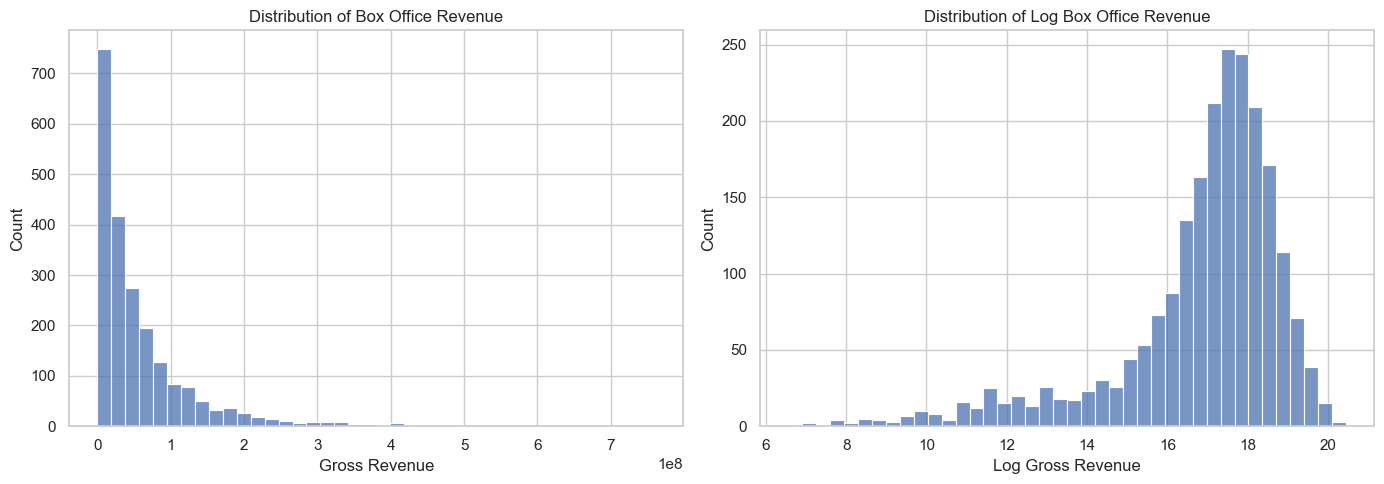

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_model["gross"], bins=40, ax=axes[0])
axes[0].set_title("Distribution of Box Office Revenue")
axes[0].set_xlabel("Gross Revenue")

sns.histplot(df_model["log_gross"], bins=40, ax=axes[1])
axes[1].set_title("Distribution of Log Box Office Revenue")
axes[1].set_xlabel("Log Gross Revenue")

plt.tight_layout()
plt.savefig(FIG_DIR / "gross_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

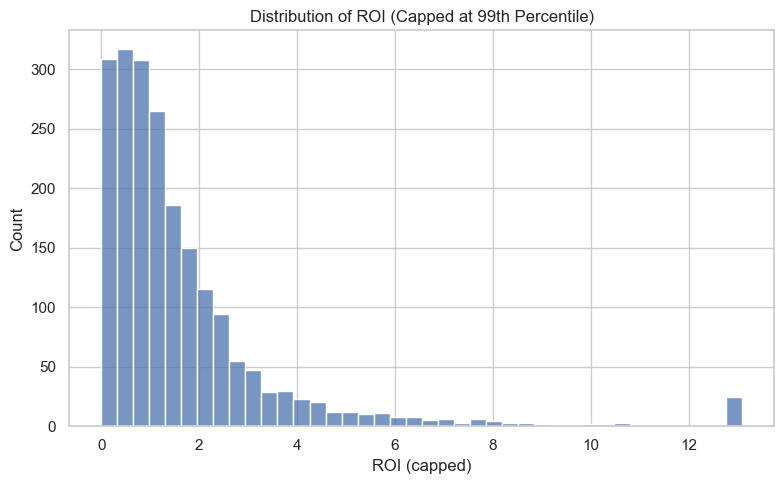

In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(roi_df["roi_capped"], bins=40)
plt.title("Distribution of ROI (Capped at 99th Percentile)")
plt.xlabel("ROI (capped)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "roi_capped_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

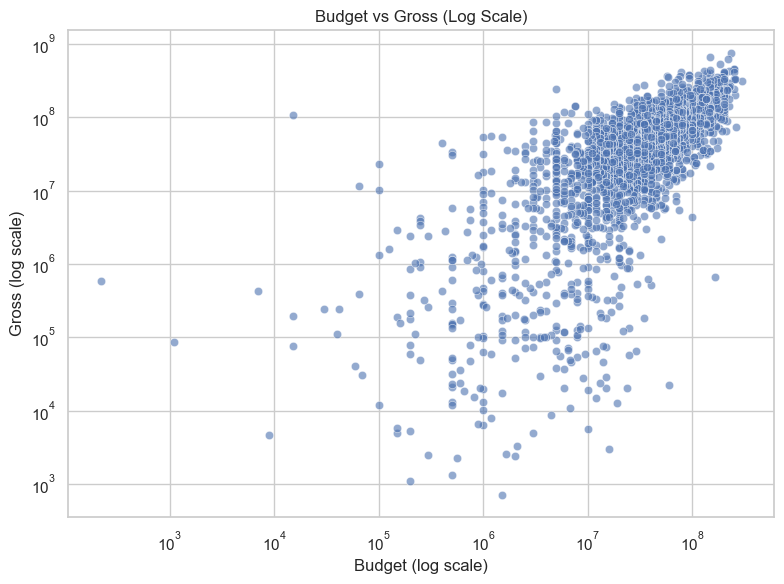

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_model,
    x="budget",
    y="gross",
    alpha=0.6
)
plt.xscale("log")
plt.yscale("log")
plt.title("Budget vs Gross (Log Scale)")
plt.xlabel("Budget (log scale)")
plt.ylabel("Gross (log scale)")
plt.tight_layout()
plt.savefig(FIG_DIR / "budget_vs_gross.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
genre_summary = (
    df_model.groupby("main_genre")
    .agg(
        movie_count=("movie_title", "count"),
        median_gross=("gross", "median"),
        avg_log_gross=("log_gross", "mean"),
        avg_imdb=("imdb_score", "mean")
    )
    .sort_values("movie_count", ascending=False)
)

genre_summary.head(10)

,movie_count,median_gross,avg_log_gross,avg_imdb
main_genre,,,,
Comedy,640,"25,431,123.00",16.43,5.98
Action,525,"58,607,007.00",17.69,6.22
Drama,366,"19,117,444.50",16.08,6.62
Adventure,218,"67,133,559.00",17.77,6.43
Crime,133,"27,154,426.00",16.17,6.79
Biography,100,"30,747,895.00",16.76,7.04
Horror,96,"31,911,647.00",16.87,5.70
Animation,28,"75,323,875.50",17.91,6.52
Documentary,28,"666,282.50",13.76,6.60


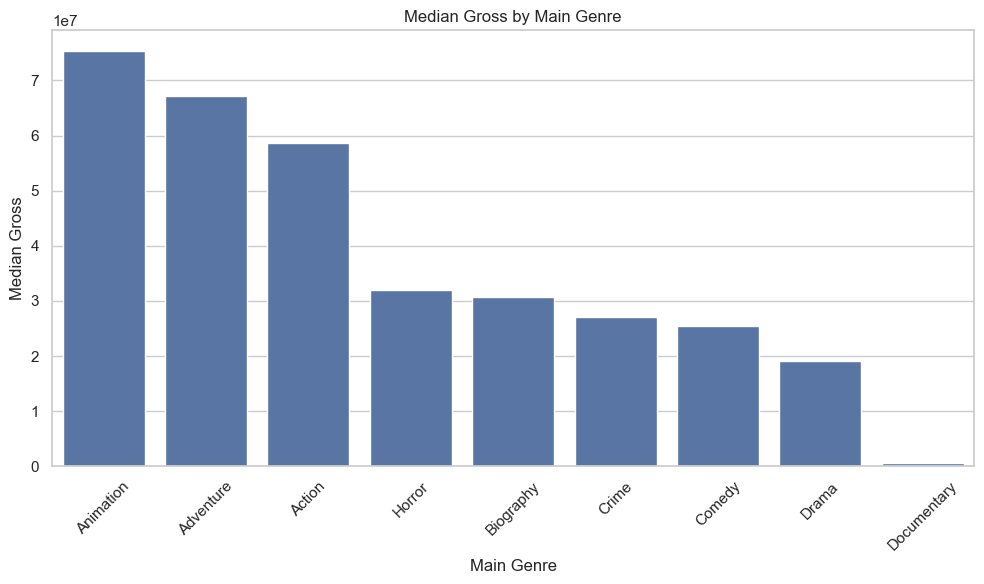

In [28]:
genre_plot_df = (
    genre_summary[genre_summary["movie_count"] >= 20]
    .sort_values("median_gross", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=genre_plot_df,
    x="main_genre",
    y="median_gross"
)
plt.title("Median Gross by Main Genre")
plt.xlabel("Main Genre")
plt.ylabel("Median Gross")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "genre_median_gross.png", dpi=300, bbox_inches="tight")
plt.show()

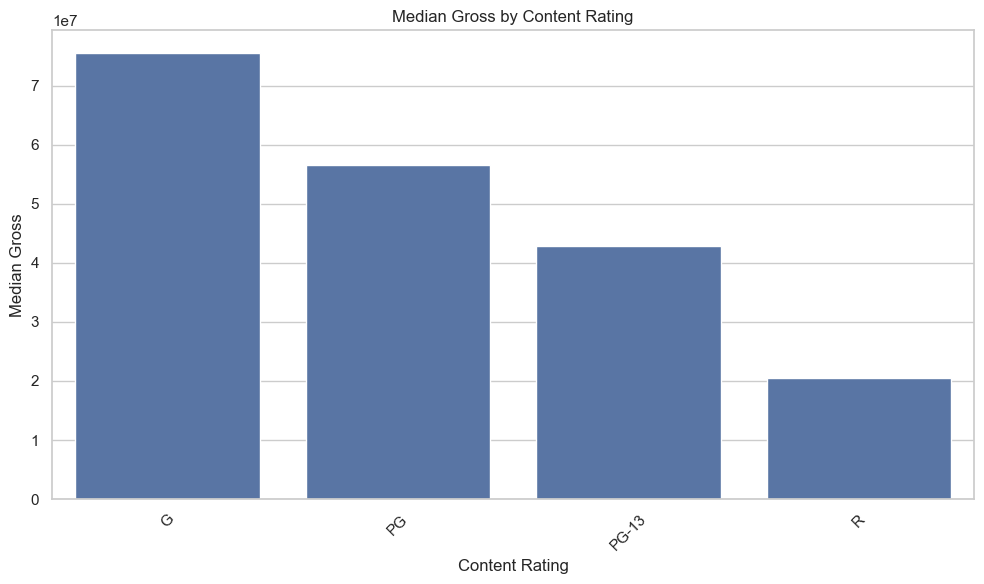

In [35]:
rating_summary = (
    df_model.groupby("content_rating")
    .agg(
        movie_count=("movie_title", "count"),
        median_gross=("gross", "median"),
        avg_log_gross=("log_gross", "mean"),
        avg_imdb=("imdb_score", "mean")
    )
    .sort_values("movie_count", ascending=False)
)

rating_summary

rating_plot_df = (
    rating_summary[rating_summary["movie_count"] >= 20]
    .sort_values("median_gross", ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=rating_plot_df,
    x="content_rating",
    y="median_gross"
)
plt.title("Median Gross by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Median Gross")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "content_rating_median_gross.png", dpi=300, bbox_inches="tight")
plt.show()

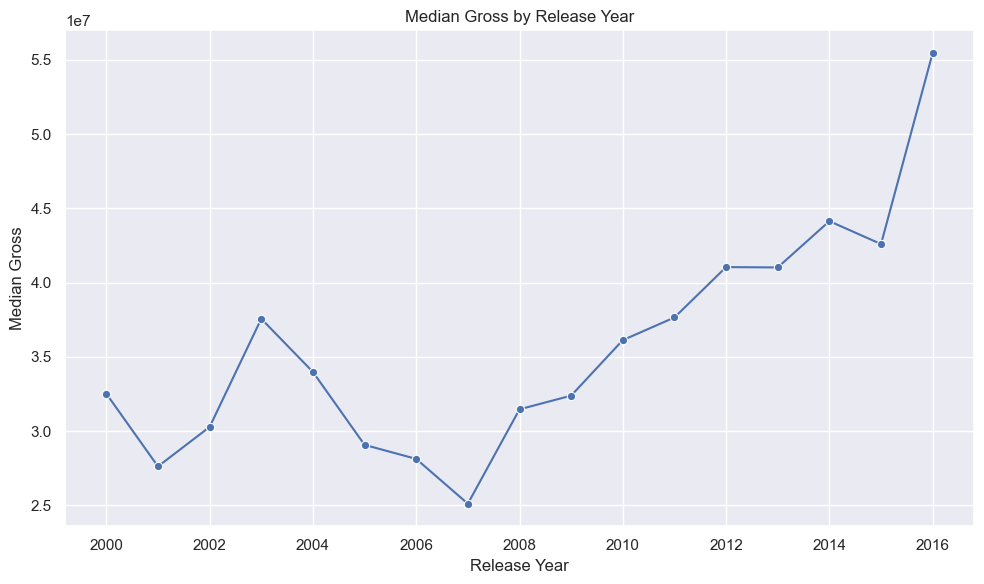

In [50]:
year_summary = (
    df_model.groupby("title_year")
    .agg(
        median_gross=("gross", "median"),
        avg_log_gross=("log_gross", "mean"),
        avg_imdb=("imdb_score", "mean"),
        movie_count=("movie_title", "count")
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=year_summary, x="title_year", y="median_gross", marker="o")
plt.title("Median Gross by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Median Gross")
plt.tight_layout()
plt.savefig(FIG_DIR / "year_median_gross.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Pre-release Modelling

A key aim of this project is to simulate a **pre-release decision scenario**. In this setting, the model should only use variables that are plausibly known before release. These include budget, duration, release year, genre, content rating, and measures of cast/director popularity.

The target variable is **log-transformed box office revenue (`log_gross`)**. A log transformation is used because revenue is highly skewed and the transformed target is more suitable for regression analysis.

Two models are estimated:

- **Linear Regression**, which provides an interpretable baseline
- **Random Forest Regressor**, which allows for more flexible nonlinear relationships



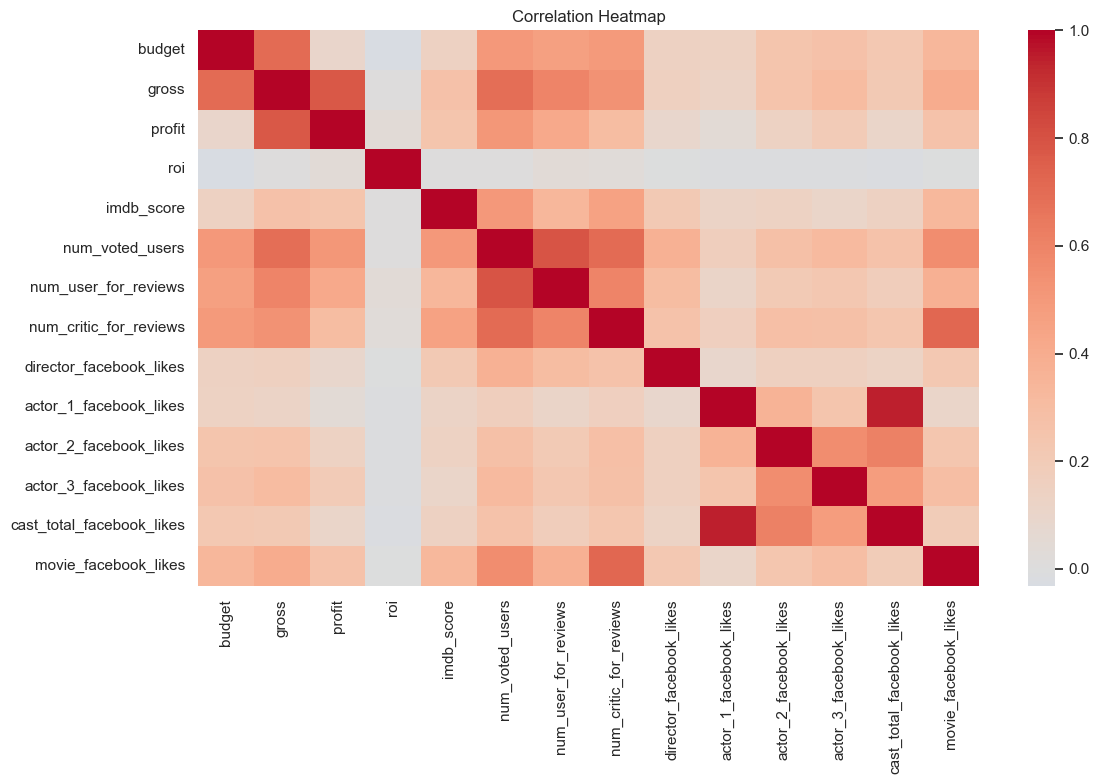

In [37]:
corr_cols = [
    "budget", "gross", "profit", "roi", "imdb_score",
    "num_voted_users", "num_user_for_reviews", "num_critic_for_reviews",
    "director_facebook_likes", "actor_1_facebook_likes",
    "actor_2_facebook_likes", "actor_3_facebook_likes",
    "cast_total_facebook_likes", "movie_facebook_likes"
]

corr_matrix = df_model[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
pre_release_features = [
    "log_budget",
    "duration",
    "title_year",
    "director_facebook_likes",
    "actor_1_facebook_likes",
    "actor_2_facebook_likes",
    "actor_3_facebook_likes",
    "cast_total_facebook_likes",
    "main_genre",
    "content_rating"
]

target = "log_gross"

model_df = df_model[pre_release_features + [target]].copy()

X = model_df[pre_release_features]
y = model_df[target]

numeric_features = [
    "log_budget",
    "duration",
    "title_year",
    "director_facebook_likes",
    "actor_1_facebook_likes",
    "actor_2_facebook_likes",
    "actor_3_facebook_likes",
    "cast_total_facebook_likes"
]

categorical_features = ["main_genre", "content_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(1736, 10) (435, 10)


In [39]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 9. Model Evaluation

Model performance is evaluated using the following metrics:

- **MAE (Mean Absolute Error)**, which measures average prediction error
- **RMSE (Root Mean Squared Error)**, which penalises larger errors more strongly
- **R-squared**, which indicates how much variation in the target is explained by the model

The comparison helps assess whether a more complex model provides clear value beyond a simpler linear benchmark.

In [40]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return pd.DataFrame({
        "model": [name],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    })

results = pd.concat([
    evaluate_model("Linear Regression", lr_pipeline, X_test, y_test),
    evaluate_model("Random Forest", rf_pipeline, X_test, y_test)
], ignore_index=True)

results.sort_values("R2", ascending=False)

,model,MAE,RMSE,R2
0,Linear Regression,0.94,1.35,0.53
1,Random Forest,0.96,1.40,0.50


## 10. Interpreting Feature Importance

After fitting the Random Forest model, feature importance values are used to identify which pre-release variables contribute most strongly to the model's predictions. These results do not prove causality, but they provide a useful ranking of influential variables in the predictive workflow.

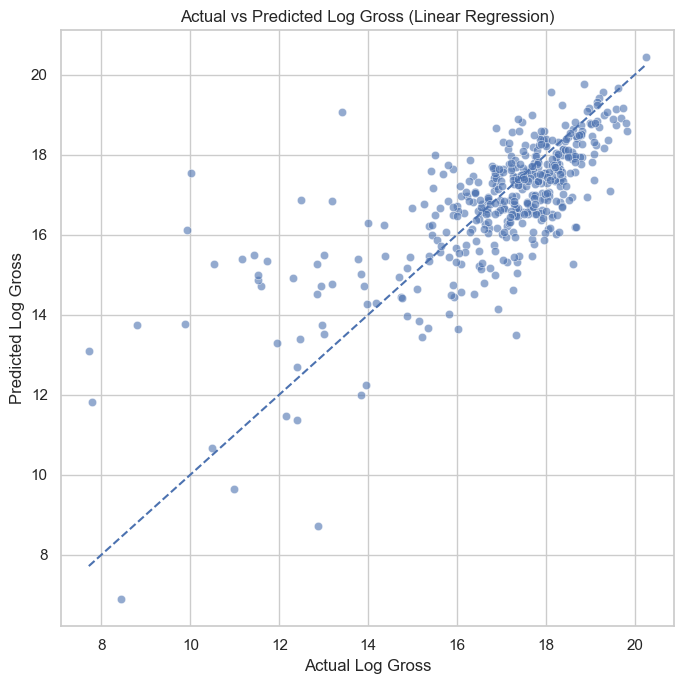

In [42]:
best_model = lr_pipeline

y_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Actual vs Predicted Log Gross (Linear Regression)")
plt.xlabel("Actual Log Gross")
plt.ylabel("Predicted Log Gross")
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted_log_gross_lr.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
# Get feature names after preprocessing
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
0,log_budget,0.59
3,director_facebook_likes,0.06
1,duration,0.05
2,title_year,0.05
6,actor_3_facebook_likes,0.05
5,actor_2_facebook_likes,0.05
7,cast_total_facebook_likes,0.04
4,actor_1_facebook_likes,0.04
18,main_genre_Horror,0.02
13,main_genre_Crime,0.01


## 11. Post-release Explanatory Analysis

The second part of the notebook moves from prediction to explanation. Here, the focus is on variables that become available after release, such as user votes, critic reviews, user reviews, and social-media attention.

These variables are analytically useful because they help explain market outcomes, but they should not be used in a true pre-release model. Including them only in the post-release section avoids data leakage and makes the project methodologically stronger.

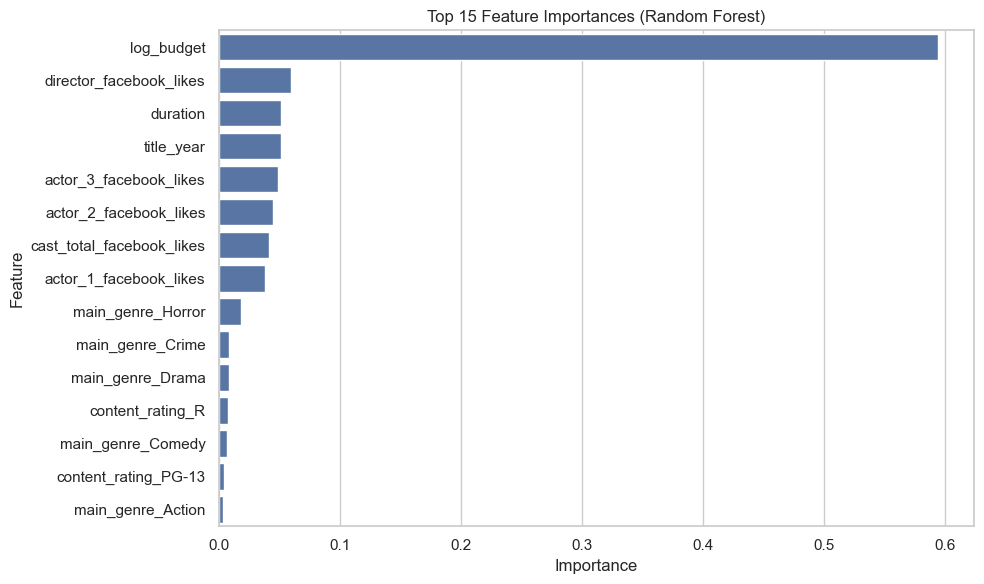

In [44]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
#Post-release explanatory analysis

In [46]:
post_release_cols = [
    "log_gross",
    "imdb_score",
    "num_voted_users",
    "num_user_for_reviews",
    "num_critic_for_reviews",
    "movie_facebook_likes"
]

post_df = df_model[post_release_cols].copy()

# Log-transform attention variables to reduce skewness
post_df["log_num_voted_users"] = np.log1p(post_df["num_voted_users"])
post_df["log_num_user_for_reviews"] = np.log1p(post_df["num_user_for_reviews"])
post_df["log_num_critic_for_reviews"] = np.log1p(post_df["num_critic_for_reviews"])
post_df["log_movie_facebook_likes"] = np.log1p(post_df["movie_facebook_likes"])

post_df.head()

,log_gross,imdb_score,num_voted_users,num_user_for_reviews,num_critic_for_reviews,movie_facebook_likes,log_num_voted_users,log_num_user_for_reviews,log_num_critic_for_reviews,log_movie_facebook_likes
0,20.45,7.90,886204,"3,054.00",723.00,33000,13.69,8.02,6.58,10.40
1,19.55,7.10,471220,"1,238.00",302.00,0,13.06,7.12,5.71,0.00
3,19.92,8.50,1144337,"2,701.00",813.00,164000,13.95,7.90,6.70,12.01
5,18.11,6.60,212204,738.00,462.00,24000,12.27,6.61,6.14,10.09
6,19.63,6.20,383056,"1,902.00",392.00,0,12.86,7.55,5.97,0.00


In [47]:
post_corr_cols = [
    "log_gross",
    "imdb_score",
    "log_num_voted_users",
    "log_num_user_for_reviews",
    "log_num_critic_for_reviews",
    "log_movie_facebook_likes"
]

post_df[post_corr_cols].corr()

,log_gross,imdb_score,log_num_voted_users,log_num_user_for_reviews,log_num_critic_for_reviews,log_movie_facebook_likes
log_gross,1.00,0.14,0.71,0.64,0.60,0.11
imdb_score,0.14,1.00,0.42,0.34,0.40,0.19
log_num_voted_users,0.71,0.42,1.00,0.88,0.87,0.22
log_num_user_for_reviews,0.64,0.34,0.88,1.00,0.77,0.15
log_num_critic_for_reviews,0.60,0.40,0.87,0.77,1.00,0.30
log_movie_facebook_likes,0.11,0.19,0.22,0.15,0.30,1.00


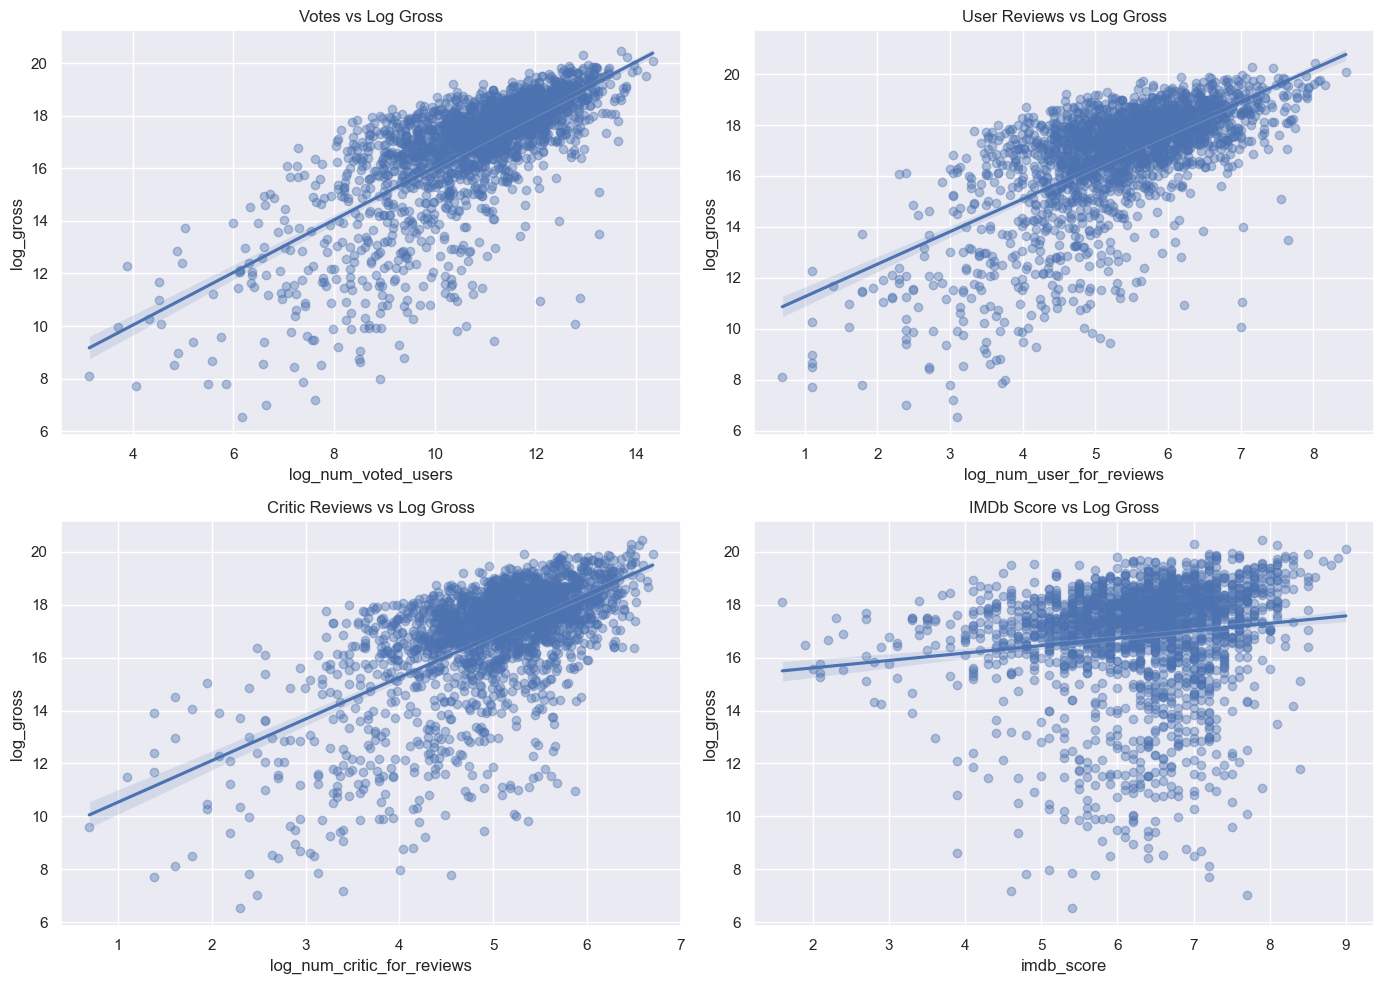

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.regplot(data=post_df, x="log_num_voted_users", y="log_gross", scatter_kws={"alpha": 0.4}, ax=axes[0, 0])
axes[0, 0].set_title("Votes vs Log Gross")

sns.regplot(data=post_df, x="log_num_user_for_reviews", y="log_gross", scatter_kws={"alpha": 0.4}, ax=axes[0, 1])
axes[0, 1].set_title("User Reviews vs Log Gross")

sns.regplot(data=post_df, x="log_num_critic_for_reviews", y="log_gross", scatter_kws={"alpha": 0.4}, ax=axes[1, 0])
axes[1, 0].set_title("Critic Reviews vs Log Gross")

sns.regplot(data=post_df, x="imdb_score", y="log_gross", scatter_kws={"alpha": 0.4}, ax=axes[1, 1])
axes[1, 1].set_title("IMDb Score vs Log Gross")

plt.tight_layout()
plt.savefig(FIG_DIR / "post_release_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Summary of Key Outputs

The final tables provide a simple business-facing summary of the sample, including top-performing films by gross revenue and by return on investment. These outputs are useful for communicating findings to non-technical users and for supporting the broader product-style presentation of the GitHub project.

In [49]:
top10_gross = df_model[
    ["movie_title", "title_year", "main_genre", "budget", "gross", "profit", "imdb_score"]
].sort_values("gross", ascending=False).head(10)

top10_roi = roi_df[
    ["movie_title", "title_year", "main_genre", "budget", "gross", "roi", "imdb_score"]
].sort_values("roi", ascending=False).head(10)

print("Top 10 by Gross")
display(top10_gross)

print("\nTop 10 by ROI (budget >= 1,000,000)")
display(top10_roi)

Top 10 by Gross


,movie_title,title_year,main_genre,budget,gross,profit,imdb_score
0,Avatar,"2,009.00",Action,"237,000,000.00","760,505,847.00","523,505,847.00",7.90
29,Jurassic World,"2,015.00",Action,"150,000,000.00","652,177,271.00","502,177,271.00",7.00
17,The Avengers,"2,012.00",Action,"220,000,000.00","623,279,547.00","403,279,547.00",8.10
66,The Dark Knight,"2,008.00",Action,"185,000,000.00","533,316,061.00","348,316,061.00",9.00
8,Avengers: Age of Ultron,"2,015.00",Action,"250,000,000.00","458,991,599.00","208,991,599.00",7.50
3,The Dark Knight Rises,"2,012.00",Action,"250,000,000.00","448,130,642.00","198,130,642.00",8.50
582,Shrek 2,"2,004.00",Adventure,"150,000,000.00","436,471,036.00","286,471,036.00",7.20
186,The Hunger Games: Catching Fire,"2,013.00",Adventure,"130,000,000.00","424,645,577.00","294,645,577.00",7.60
13,Pirates of the Caribbean: Dead Man's Chest,"2,006.00",Action,"225,000,000.00","423,032,628.00","198,032,628.00",7.30
43,Toy Story 3,"2,010.00",Adventure,"200,000,000.00","414,984,497.00","214,984,497.00",8.30



Top 10 by ROI (budget >= 1,000,000)


,movie_title,title_year,main_genre,budget,gross,roi,imdb_score
4545,The Devil Inside,"2,012.00",Horror,"1,000,000.00","53,245,055.00",53.25,4.20
3737,My Big Fat Greek Wedding,"2,002.00",Comedy,"5,000,000.00","241,437,427.00",48.29,6.60
4485,Saw,"2,004.00",Horror,"1,200,000.00","55,153,403.00",45.96,7.70
4413,Insidious,"2,010.00",Fantasy,"1,500,000.00","53,991,137.00",35.99,6.80
4534,Unfriended,"2,014.00",Horror,"1,000,000.00","31,537,320.00",31.54,5.70
4052,Paranormal Activity 2,"2,010.00",Horror,"3,000,000.00","84,749,884.00",28.25,5.70
3697,Saw II,"2,005.00",Horror,"4,000,000.00","87,025,093.00",21.76,6.60
4058,The Purge,"2,013.00",Horror,"3,000,000.00","64,423,650.00",21.47,5.70
4381,In the Bedroom,"2,001.00",Crime,"1,700,000.00","35,918,429.00",21.13,7.50
3701,Paranormal Activity 3,"2,011.00",Horror,"5,000,000.00","104,007,828.00",20.80,5.80


## 13. Conclusion

This notebook demonstrates a complete Python workflow for transforming raw movie metadata into business-relevant insight. The project shows that movie success can be studied from two complementary angles: **pre-release estimation** and **post-release explanation**.

Overall, the notebook supports three main ideas:

1. Pre-release variables such as budget, genre, content rating, and cast popularity provide useful but imperfect signals of box office performance.
2. Post-release attention indicators, including votes and reviews, are strongly associated with commercial outcomes and help explain market traction.
3. A clear separation between predictive and explanatory analysis improves the reliability and professional quality of the project.

Despite these strengths, the analysis also has limitations. Financial variables may contain outliers, monetary values are not adjusted for inflation, and some popularity measures may not be equally meaningful across all years. Therefore, the results should be interpreted as business-oriented evidence of association rather than strict causal proof.